# Packages

In [5]:
import pandas as pd
import numpy as np 
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path


from matplotlib import rcParams

rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

# Data

In [6]:
# setting up addresses
proj_folder   = Path("/home/janzules/spatial/CAR-T/data/cell2location")

epoch_num = 50

# Model Output location
ref_run_name   = proj_folder / "reference_signatures"
run_name       = proj_folder / "cell2location_map"

# Files
adata_file = run_name / f"sp_{epoch_num}_epochs.h5ad"



In [7]:
# Load data
adata_vis = sc.read_h5ad(adata_file)

In [12]:
adata_vis

AnnData object with n_obs × n_vars = 427296 × 12128
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'treatment', 'batch_core', 'mt_counts', '_indices', '_scvi_batch', '_scvi_labels'
    var: 'SYMBOL'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'mod', 'spatialdata_attrs'
    obsm: 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q50_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'spatial', 'stds_cell_abundance_w_sf'

In [11]:
adata_vis.obsm.keys()

KeysView(AxisArrays with keys: means_cell_abundance_w_sf, q05_cell_abundance_w_sf, q50_cell_abundance_w_sf, q95_cell_abundance_w_sf, spatial, stds_cell_abundance_w_sf)

In [13]:
adata_vis.obsm['q50_cell_abundance_w_sf'].head()

,q50cell_abundance_w_sf_B/T_cell,q50cell_abundance_w_sf_B_cell,q50cell_abundance_w_sf_CAR_T_cell,q50cell_abundance_w_sf_DC,q50cell_abundance_w_sf_Endothelial,q50cell_abundance_w_sf_Erythrocyte,q50cell_abundance_w_sf_Fibroblast,q50cell_abundance_w_sf_Macrophage,q50cell_abundance_w_sf_Monocyte,q50cell_abundance_w_sf_NK_cell,q50cell_abundance_w_sf_Neutrophils,q50cell_abundance_w_sf_T_cell
F07839_cellid_000000001-1,0.129730,0.138700,0.169202,0.143667,0.152382,0.089727,0.192568,0.161256,0.137519,0.172585,0.088653,0.150131
F07839_cellid_000000002-1,0.140324,0.123493,0.119080,0.128275,0.135243,0.089113,0.190289,0.114721,0.112864,0.197732,0.085870,0.183162
F07839_cellid_000000004-1,0.080296,0.080972,0.089373,0.086443,0.103629,0.193218,0.186900,0.088796,0.093036,0.078512,0.086428,0.079821
F07839_cellid_000000005-1,0.104845,0.112050,0.105143,0.131018,0.107835,0.085026,0.106375,0.116608,0.161824,0.191468,0.110544,0.148361
F07839_cellid_000000006-1,0.109343,0.111353,0.101093,0.133965,0.130345,0.080530,0.172025,0.093570,0.152432,0.124406,0.109024,0.114416


# Looking c2l output

In [14]:
import numpy as np
import pandas as pd

def clean_cols(df):
    df = df.copy()
    df.columns = [c.split("w_sf_")[-1] for c in df.columns]
    return df

w = clean_cols(adata_vis.obsm["means_cell_abundance_w_sf"])
total = w.sum(axis=1)
total.describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])


count    427296.000000
mean          1.398394
std           0.478674
min           0.805028
1%            0.854612
5%            0.873224
10%           0.895015
25%           0.996874
50%           1.304518
75%           1.610943
90%           2.185626
95%           2.442166
99%           2.678682
max           2.954294
dtype: float64

In [15]:
vals = np.sort(w.to_numpy(), axis=1)
margin = vals[:, -1] - vals[:, -2]
pd.Series(margin).describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])


count    4.272960e+05
mean     2.388054e-02
std      2.712289e-02
min      2.980232e-08
1%       7.615238e-05
5%       3.995001e-04
10%      8.637607e-04
25%      2.834691e-03
50%      1.291791e-02
75%      3.697268e-02
90%      6.451277e-02
95%      8.246324e-02
99%      1.097034e-01
max      1.840407e-01
dtype: float64

In [16]:
w05 = clean_cols(adata_vis.obsm["q05_cell_abundance_w_sf"])
winner = w.idxmax(axis=1).to_numpy()
idx = pd.Index(w05.columns).get_indexer(winner)
rows = np.arange(adata_vis.n_obs)
q05_winner = w05.to_numpy()[rows, idx]
pd.Series(q05_winner).describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])


count    427296.000000
mean          0.133662
std           0.045443
min           0.051029
1%            0.058087
5%            0.061265
10%           0.063741
25%           0.082679
50%           0.152737
75%           0.171280
90%           0.180597
95%           0.186048
99%           0.197733
max           0.227127
dtype: float64

# Generating figures

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def clean_cols(df):
    df = df.copy()
    df.columns = [c.split("w_sf_")[-1] for c in df.columns]
    return df

w_mean = clean_cols(adata_vis.obsm["means_cell_abundance_w_sf"])
w05    = clean_cols(adata_vis.obsm["q05_cell_abundance_w_sf"])
w95    = clean_cols(adata_vis.obsm["q95_cell_abundance_w_sf"])

# total inferred abundance per cell
total = w_mean.sum(axis=1)

# argmax label + top score (mean)
label = w_mean.idxmax(axis=1)
score = w_mean.max(axis=1)

# dominance / ambiguity: top1 - top2
vals = np.sort(w_mean.to_numpy(), axis=1)
margin = vals[:, -1] - vals[:, -2]

# conservative confidence: q05 of the winning label
idx = pd.Index(w05.columns).get_indexer(label.to_numpy())
rows = np.arange(adata_vis.n_obs)
q05_winner = w05.to_numpy()[rows, idx]

# store in obs for later plotting
adata_vis.obs["c2l_total_mean"] = total.to_numpy()
adata_vis.obs["c2l_label_mean"] = label.astype(str).to_numpy()
adata_vis.obs["c2l_score_mean"] = score.to_numpy()
adata_vis.obs["c2l_margin_mean"] = margin
adata_vis.obs["c2l_q05_winner"] = q05_winner

adata_vis.obs[["c2l_total_mean","c2l_score_mean","c2l_margin_mean","c2l_q05_winner"]].describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])


,c2l_total_mean,c2l_score_mean,c2l_margin_mean,c2l_q05_winner
count,427296.000000,427296.000000,4.272960e+05,427296.000000
mean,1.398394,0.162946,2.388054e-02,0.133662
std,0.478674,0.053183,2.712289e-02,0.045443
min,0.805028,0.069479,2.980232e-08,0.051029
1%,0.854612,0.074644,7.615238e-05,0.058087
5%,0.873224,0.077166,3.995001e-04,0.061265
10%,0.895015,0.079906,8.637607e-04,0.063741
25%,0.996874,0.103470,2.834691e-03,0.082679
50%,1.304518,0.186555,1.291791e-02,0.152737
75%,1.610943,0.206360,3.697268e-02,0.171280


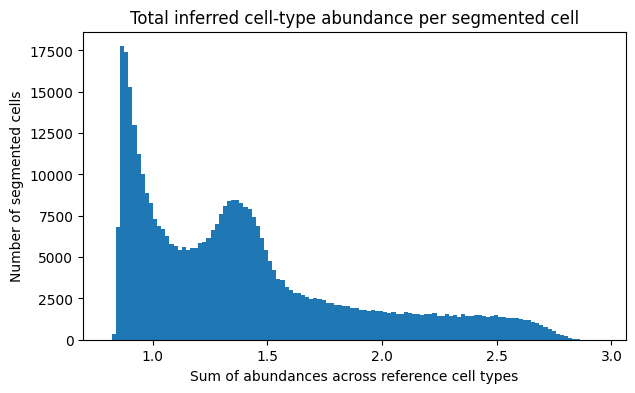

In [18]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(adata_vis.obs["c2l_total_mean"], bins=120)
ax.set_title("Total inferred cell-type abundance per segmented cell")
ax.set_xlabel("Sum of abundances across reference cell types")
ax.set_ylabel("Number of segmented cells")
plt.show()


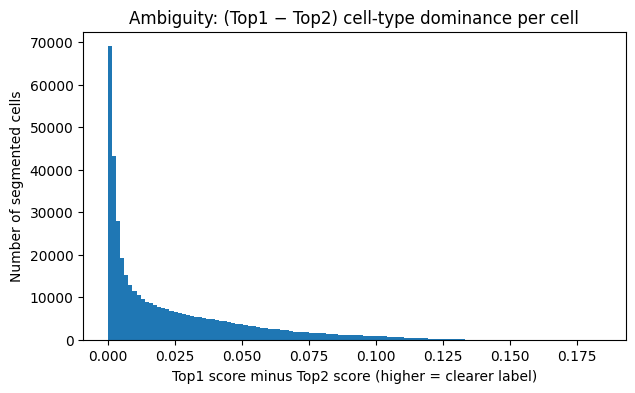

In [20]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(adata_vis.obs["c2l_margin_mean"], bins=120)
ax.set_title("Ambiguity: (Top1 − Top2) cell-type dominance per cell")
ax.set_xlabel("Top1 score minus Top2 score (higher = clearer label)")
ax.set_ylabel("Number of segmented cells")
plt.show()


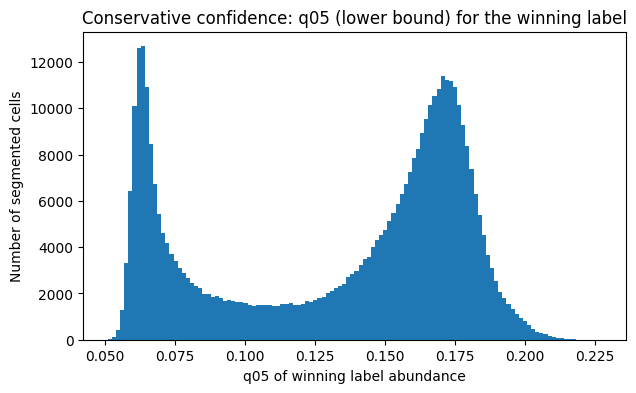

In [21]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(adata_vis.obs["c2l_q05_winner"], bins=120)
ax.set_title("Conservative confidence: q05 (lower bound) for the winning label")
ax.set_xlabel("q05 of winning label abundance")
ax.set_ylabel("Number of segmented cells")
plt.show()


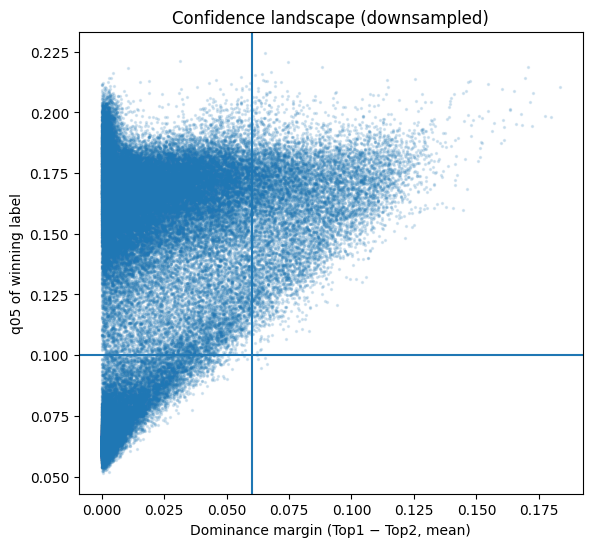

In [22]:
# downsample for scatter
n = adata_vis.n_obs
rng = np.random.default_rng(0)
take = rng.choice(n, size=min(n, 80_000), replace=False)

x = adata_vis.obs["c2l_margin_mean"].to_numpy()[take]
y = adata_vis.obs["c2l_q05_winner"].to_numpy()[take]

# choose example strict cutoffs (tune these)
m_cut = 0.06
q_cut = 0.10

fig, ax = plt.subplots(figsize=(6.5,6))
ax.scatter(x, y, s=2, alpha=0.15)
ax.axvline(m_cut)
ax.axhline(q_cut)
ax.set_title("Confidence landscape (downsampled)")
ax.set_xlabel("Dominance margin (Top1 − Top2, mean)")
ax.set_ylabel("q05 of winning label")
plt.show()


In [23]:
m_cut = 0.06
q_cut = 0.10

conf = (adata_vis.obs["c2l_margin_mean"] >= m_cut) & (adata_vis.obs["c2l_q05_winner"] >= q_cut)

adata_vis.obs["c2l_label_strict"] = "Unassigned"
adata_vis.obs.loc[conf, "c2l_label_strict"] = adata_vis.obs.loc[conf, "c2l_label_mean"]

print("Fraction assigned:", conf.mean())
adata_vis.obs["c2l_label_strict"].value_counts().head(20)


Fraction assigned: 0.11745487905339624


c2l_label_strict
Unassigned     377108
Fibroblast      44441
Erythrocyte      2679
Endothelial      1216
Macrophage       1164
NK_cell           515
Neutrophils       116
CAR_T_cell         49
Monocyte            7
T_cell              1
Name: count, dtype: int64

# What's going on with the T cells

In [24]:
w = clean_cols(adata_vis.obsm["means_cell_abundance_w_sf"])
w.idxmax(axis=1).value_counts().head(20)

Fibroblast     219966
Erythrocyte     72007
Neutrophils     42202
CAR_T_cell      22507
Macrophage      20436
Endothelial     12547
Monocyte        12356
NK_cell          9544
B_cell           5853
B/T_cell         4022
T_cell           3975
DC               1881
Name: count, dtype: int64

In [25]:
w = clean_cols(adata_vis.obsm["means_cell_abundance_w_sf"])
w05 = clean_cols(adata_vis.obsm["q05_cell_abundance_w_sf"])

winner = w.idxmax(axis=1)
arr = w.to_numpy()
vals = np.sort(arr, axis=1)
margin = vals[:, -1] - vals[:, -2]

# q05 for winner
idx = pd.Index(w05.columns).get_indexer(winner.to_numpy())
rows = np.arange(adata_vis.n_obs)
q05_winner = w05.to_numpy()[rows, idx]

mask_bt = (winner == "B/T_cell").to_numpy()

print("B/T_cell winner count:", mask_bt.sum())
print("Margin stats for B/T_cell winners:")
print(pd.Series(margin[mask_bt]).describe(percentiles=[.5,.75,.9,.95,.99]))
print("q05_winner stats for B/T_cell winners:")
print(pd.Series(q05_winner[mask_bt]).describe(percentiles=[.5,.75,.9,.95,.99]))

# fraction that would pass your strict cutoffs
m_cut = 0.06
q_cut = 0.10
print("Fraction of B/T_cell winners passing strict:",
      ((margin[mask_bt] >= m_cut) & (q05_winner[mask_bt] >= q_cut)).mean())


B/T_cell winner count: 4022
Margin stats for B/T_cell winners:
count    4.022000e+03
mean     1.854689e-03
std      1.885380e-03
min      8.195639e-08
50%      1.198351e-03
75%      2.685346e-03
90%      4.451351e-03
95%      5.817620e-03
99%      8.384061e-03
max      1.359187e-02
dtype: float64
q05_winner stats for B/T_cell winners:
count    4022.000000
mean        0.159218
std         0.051275
min         0.057057
50%         0.183114
75%         0.192785
90%         0.199507
95%         0.203132
99%         0.208940
max         0.215414
dtype: float64
Fraction of B/T_cell winners passing strict: 0.0


In [26]:
cols = np.array(w.columns)
top2 = np.argpartition(arr, kth=-2, axis=1)[:, -2:]
top2_labels = cols[top2]

# for B/T_cell winners, find the runner-up label
# identify which of the two is the winner vs runner-up
bt_top2 = top2_labels[mask_bt]
bt_vals_top2 = arr[mask_bt][:, top2[mask_bt] ]  # careful indexing might be messy; simpler approach:

# simpler: just take second best label from full sort
second_idx = np.argsort(arr[mask_bt], axis=1)[:, -2]
runner_up = cols[second_idx]
print(pd.Series(runner_up).value_counts().head(10))


Erythrocyte    700
B_cell         663
T_cell         500
Neutrophils    470
CAR_T_cell     450
NK_cell        440
DC             240
Fibroblast     179
Monocyte       157
Endothelial    150
Name: count, dtype: int64
